[1850 1851 1852 1853 1854 1855 1856 1857 1858 1859 1860 1861 1862 1863
 1864 1865 1866 1867 1868 1869 1870 1871 1872 1873 1874 1875 1876 1877
 1878 1879 1880 1881 1882 1883 1884 1885 1886 1887 1888 1889 1890 1891
 1892 1893 1894 1895 1896 1897 1898 1899 1900 1901 1902 1903 1904 1905
 1906 1907 1908 1909 1910 1911 1912 1913 1914 1915 1916 1917 1918 1919
 1920 1921 1922 1923 1924 1925 1926 1927 1928 1929 1930 1931 1932 1933
 1934 1935 1936 1937 1938 1939 1940 1941 1942 1943 1944 1945 1946 1947
 1948 1949 1950 1951 1952 1953 1954 1955 1956 1957 1958 1959 1960 1961
 1962 1963 1964 1965 1966 1967 1968 1969 1970 1971 1972 1973 1974 1975
 1976 1977 1978 1979 1980 1981 1982 1983 1984 1985 1986 1987 1988 1989
 1990 1991 1992 1993 1994 1995 1996 1997 1998 1999 2000 2001 2002 2003
 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013 2014 2015 2016 2017
 2018 2019 2020 2021 2022 2023 2024 2025 2026 2027 2028 2029 2030 2031
 2032 2033 2034 2035 2036 2037 2038 2039 2040 2041 2042 2043 2044 2045
 2046 

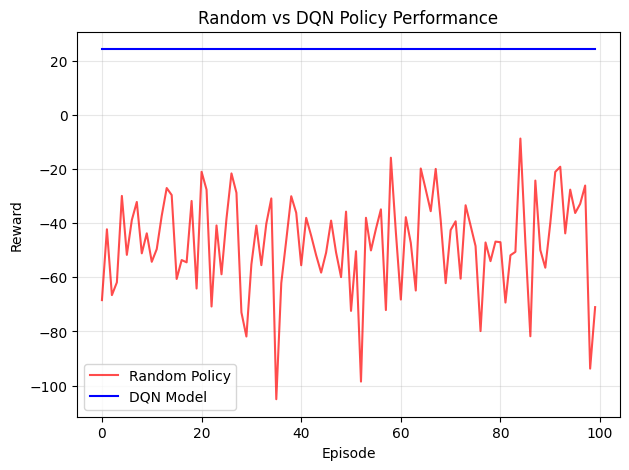

In [3]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import odeint
import scipy.io
from matplotlib.gridspec import GridSpec
import math
import random
import torch
from stable_baselines3.common.env_checker import check_env
from stable_baselines3.common.logger import configure
from stable_baselines3.common.monitor import Monitor
from stable_baselines3 import PPO 
from stable_baselines3 import DQN
# 导入 BaseCallback
from stable_baselines3.common.callbacks import BaseCallback
import sys
import os
# 导入 IEMEnv 类
from src.envs.iseec_lx_v4_pomdp import IEMEnv
from src.utils.run_debug_plot import save_data 
from src.utils.run_debug_plot import save_plot_NSM_data
from src.utils.run_debug_plot import save_plot_SSM_data
from src.utils.run_debug_plot import save_future_data
from src.utils.run_debug_plot import save_plot_NSM_future_data
from src.utils.run_debug_plot import save_plot_SSM_future_data
from src.utils.run_debug_plot import plot_episode_reward
from src.utils.run_debug_plot import plot_episode_reward_simple
from src.utils.run_debug_plot import plot_3D_run
# 将 src 目录添加到模块搜索路径
sys.path.append(os.path.abspath('src'))


# 参数配置部分
custom_reward_type = "multi_objective_single_T_a_exp822"
log_name = "iseec_lx_v4_mdp_plot_DQN_multi_objective_single_T_a_exp822_700000_default"
seed = 42
# po_mdp_state = [0, 1, 2, 3, 4]  # POMDP 状态索引
# 加载对应环境
env = IEMEnv(reward_type=custom_reward_type, seed=seed, ) #  pomdp_state_indices=po_mdp_state
# 加载初始的模型
model = DQN.load(f"./model/{log_name}", env=env)

test_episodes = 100
max_steps = 250

random_rewards = []
dqn_rewards = []

for ep in range(test_episodes):
    # --- DQN Policy ---
    obs, _ = env.reset(use_random_reset = False)
    total_reward = 0
    done = False
    for _ in range(max_steps):
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, done, _, _ = env.step(action)
        total_reward += reward
        if done:
            break
    dqn_rewards.append(total_reward)

    # --- Random Policy ---
    obs, _ = env.reset(use_random_reset = False)
    total_reward = 0
    done = False
    for _ in range(max_steps):
        action = env.action_space.sample()
        obs, reward, done, _, _ = env.step(action)
        total_reward += reward
        if done:
            break
    random_rewards.append(total_reward)

# 绘图
plt.figure(figsize=(7,5))
plt.plot(range(test_episodes), random_rewards, label="Random Policy", color='red', alpha=0.7)
plt.plot(range(test_episodes), dqn_rewards, label="DQN Model", color='blue')
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Random vs DQN Policy Performance")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

[1850 1851 1852 1853 1854 1855 1856 1857 1858 1859 1860 1861 1862 1863
 1864 1865 1866 1867 1868 1869 1870 1871 1872 1873 1874 1875 1876 1877
 1878 1879 1880 1881 1882 1883 1884 1885 1886 1887 1888 1889 1890 1891
 1892 1893 1894 1895 1896 1897 1898 1899 1900 1901 1902 1903 1904 1905
 1906 1907 1908 1909 1910 1911 1912 1913 1914 1915 1916 1917 1918 1919
 1920 1921 1922 1923 1924 1925 1926 1927 1928 1929 1930 1931 1932 1933
 1934 1935 1936 1937 1938 1939 1940 1941 1942 1943 1944 1945 1946 1947
 1948 1949 1950 1951 1952 1953 1954 1955 1956 1957 1958 1959 1960 1961
 1962 1963 1964 1965 1966 1967 1968 1969 1970 1971 1972 1973 1974 1975
 1976 1977 1978 1979 1980 1981 1982 1983 1984 1985 1986 1987 1988 1989
 1990 1991 1992 1993 1994 1995 1996 1997 1998 1999 2000 2001 2002 2003
 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013 2014 2015 2016 2017
 2018 2019 2020 2021 2022 2023 2024 2025 2026 2027 2028 2029 2030 2031
 2032 2033 2034 2035 2036 2037 2038 2039 2040 2041 2042 2043 2044 2045
 2046 

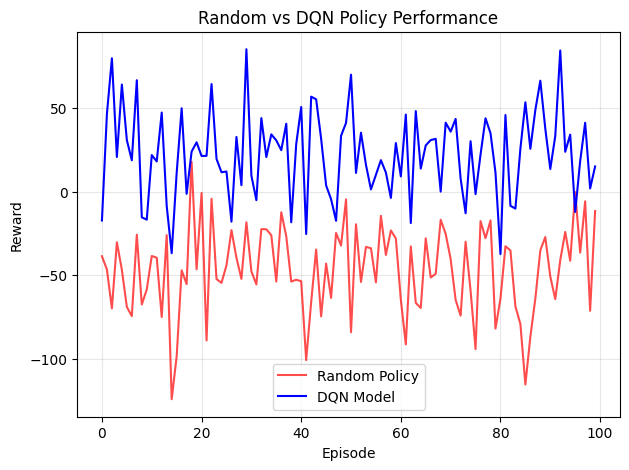

In [4]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import odeint
import scipy.io
from matplotlib.gridspec import GridSpec
import math
import random
import torch
from stable_baselines3.common.env_checker import check_env
from stable_baselines3.common.logger import configure
from stable_baselines3.common.monitor import Monitor
from stable_baselines3 import PPO 
from stable_baselines3 import DQN
# 导入 BaseCallback
from stable_baselines3.common.callbacks import BaseCallback
import sys
import os
# 导入 IEMEnv 类
from src.envs.iseec_lx_v4_pomdp import IEMEnv
from src.utils.run_debug_plot import save_data 
from src.utils.run_debug_plot import save_plot_NSM_data
from src.utils.run_debug_plot import save_plot_SSM_data
from src.utils.run_debug_plot import save_future_data
from src.utils.run_debug_plot import save_plot_NSM_future_data
from src.utils.run_debug_plot import save_plot_SSM_future_data
from src.utils.run_debug_plot import plot_episode_reward
from src.utils.run_debug_plot import plot_episode_reward_simple
from src.utils.run_debug_plot import plot_3D_run
# 将 src 目录添加到模块搜索路径
sys.path.append(os.path.abspath('src'))


# 参数配置部分
custom_reward_type = "multi_objective_single_T_a_exp822"
log_name = "iseec_lx_v4_mdp_plot_DQN_multi_objective_single_T_a_exp822_700000_default"
seed = 42
# po_mdp_state = [0, 1, 2, 3, 4]  # POMDP 状态索引
# 加载对应环境
env = IEMEnv(reward_type=custom_reward_type, seed=seed, ) #  pomdp_state_indices=po_mdp_state
# 加载初始的模型
model = DQN.load(f"./model/{log_name}", env=env)

test_episodes = 100
max_steps = 250

random_rewards = []
dqn_rewards = []

for ep in range(test_episodes):
    # --- DQN Policy ---
    obs, _ = env.reset()
    total_reward = 0
    done = False
    for _ in range(max_steps):
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, done, _, _ = env.step(action)
        total_reward += reward
        if done:
            break
    dqn_rewards.append(total_reward)

    # --- Random Policy ---
    obs, _ = env.reset()
    total_reward = 0
    done = False
    for _ in range(max_steps):
        action = env.action_space.sample()
        obs, reward, done, _, _ = env.step(action)
        total_reward += reward
        if done:
            break
    random_rewards.append(total_reward)

# 绘图
plt.figure(figsize=(7,5))
plt.plot(range(test_episodes), random_rewards, label="Random Policy", color='red', alpha=0.7)
plt.plot(range(test_episodes), dqn_rewards, label="DQN Model", color='blue')
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Random vs DQN Policy Performance")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

[1850 1851 1852 1853 1854 1855 1856 1857 1858 1859 1860 1861 1862 1863
 1864 1865 1866 1867 1868 1869 1870 1871 1872 1873 1874 1875 1876 1877
 1878 1879 1880 1881 1882 1883 1884 1885 1886 1887 1888 1889 1890 1891
 1892 1893 1894 1895 1896 1897 1898 1899 1900 1901 1902 1903 1904 1905
 1906 1907 1908 1909 1910 1911 1912 1913 1914 1915 1916 1917 1918 1919
 1920 1921 1922 1923 1924 1925 1926 1927 1928 1929 1930 1931 1932 1933
 1934 1935 1936 1937 1938 1939 1940 1941 1942 1943 1944 1945 1946 1947
 1948 1949 1950 1951 1952 1953 1954 1955 1956 1957 1958 1959 1960 1961
 1962 1963 1964 1965 1966 1967 1968 1969 1970 1971 1972 1973 1974 1975
 1976 1977 1978 1979 1980 1981 1982 1983 1984 1985 1986 1987 1988 1989
 1990 1991 1992 1993 1994 1995 1996 1997 1998 1999 2000 2001 2002 2003
 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013 2014 2015 2016 2017
 2018 2019 2020 2021 2022 2023 2024 2025 2026 2027 2028 2029 2030 2031
 2032 2033 2034 2035 2036 2037 2038 2039 2040 2041 2042 2043 2044 2045
 2046 

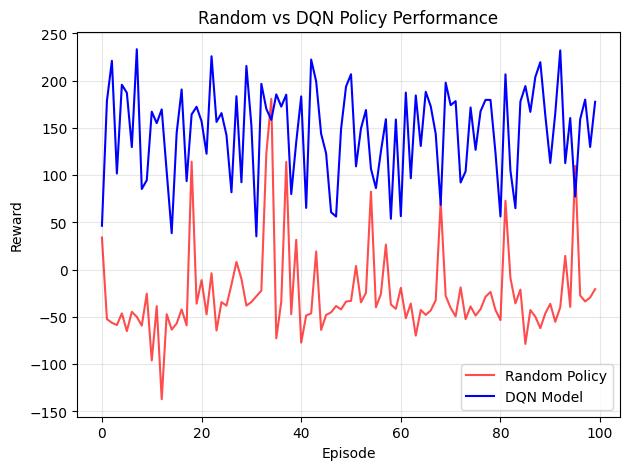

In [5]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import odeint
import scipy.io
from matplotlib.gridspec import GridSpec
import math
import random
import torch
from stable_baselines3.common.env_checker import check_env
from stable_baselines3.common.logger import configure
from stable_baselines3.common.monitor import Monitor
from stable_baselines3 import PPO 
from stable_baselines3 import DQN
# 导入 BaseCallback
from stable_baselines3.common.callbacks import BaseCallback
import sys
import os
# 导入 IEMEnv 类
from src.envs.iseec_lx_v4_pomdp import IEMEnv
from src.utils.run_debug_plot import save_data 
from src.utils.run_debug_plot import save_plot_NSM_data
from src.utils.run_debug_plot import save_plot_SSM_data
from src.utils.run_debug_plot import save_future_data
from src.utils.run_debug_plot import save_plot_NSM_future_data
from src.utils.run_debug_plot import save_plot_SSM_future_data
from src.utils.run_debug_plot import plot_episode_reward
from src.utils.run_debug_plot import plot_episode_reward_simple
from src.utils.run_debug_plot import plot_3D_run
# 将 src 目录添加到模块搜索路径
sys.path.append(os.path.abspath('src'))


# 参数配置部分
custom_reward_type = "multi_objective_all_T_a_Ca_exp122_weights_change_more_ta"
log_name = "iseec_lx_v4_mdp_plot_DQN_multi_objective_all_T_a_Ca_exp122_weights_change_more_ta_700000_default"
seed = 42
# po_mdp_state = [0, 1, 2, 3, 4]  # POMDP 状态索引
# 加载对应环境
env = IEMEnv(reward_type=custom_reward_type, seed=seed, ) #  pomdp_state_indices=po_mdp_state
# 加载初始的模型
model = DQN.load(f"./model/{log_name}", env=env)

test_episodes = 100
max_steps = 250

random_rewards = []
dqn_rewards = []

for ep in range(test_episodes):
    # --- DQN Policy ---
    obs, _ = env.reset()
    total_reward = 0
    done = False
    for _ in range(max_steps):
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, done, _, _ = env.step(action)
        total_reward += reward
        if done:
            break
    dqn_rewards.append(total_reward)

    # --- Random Policy ---
    obs, _ = env.reset()
    total_reward = 0
    done = False
    for _ in range(max_steps):
        action = env.action_space.sample()
        obs, reward, done, _, _ = env.step(action)
        total_reward += reward
        if done:
            break
    random_rewards.append(total_reward)

# 绘图
plt.figure(figsize=(7,5))
plt.plot(range(test_episodes), random_rewards, label="Random Policy", color='red', alpha=0.7)
plt.plot(range(test_episodes), dqn_rewards, label="DQN Model", color='blue')
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Random vs DQN Policy Performance")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

[1850 1851 1852 1853 1854 1855 1856 1857 1858 1859 1860 1861 1862 1863
 1864 1865 1866 1867 1868 1869 1870 1871 1872 1873 1874 1875 1876 1877
 1878 1879 1880 1881 1882 1883 1884 1885 1886 1887 1888 1889 1890 1891
 1892 1893 1894 1895 1896 1897 1898 1899 1900 1901 1902 1903 1904 1905
 1906 1907 1908 1909 1910 1911 1912 1913 1914 1915 1916 1917 1918 1919
 1920 1921 1922 1923 1924 1925 1926 1927 1928 1929 1930 1931 1932 1933
 1934 1935 1936 1937 1938 1939 1940 1941 1942 1943 1944 1945 1946 1947
 1948 1949 1950 1951 1952 1953 1954 1955 1956 1957 1958 1959 1960 1961
 1962 1963 1964 1965 1966 1967 1968 1969 1970 1971 1972 1973 1974 1975
 1976 1977 1978 1979 1980 1981 1982 1983 1984 1985 1986 1987 1988 1989
 1990 1991 1992 1993 1994 1995 1996 1997 1998 1999 2000 2001 2002 2003
 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013 2014 2015 2016 2017
 2018 2019 2020 2021 2022 2023 2024 2025 2026 2027 2028 2029 2030 2031
 2032 2033 2034 2035 2036 2037 2038 2039 2040 2041 2042 2043 2044 2045
 2046 

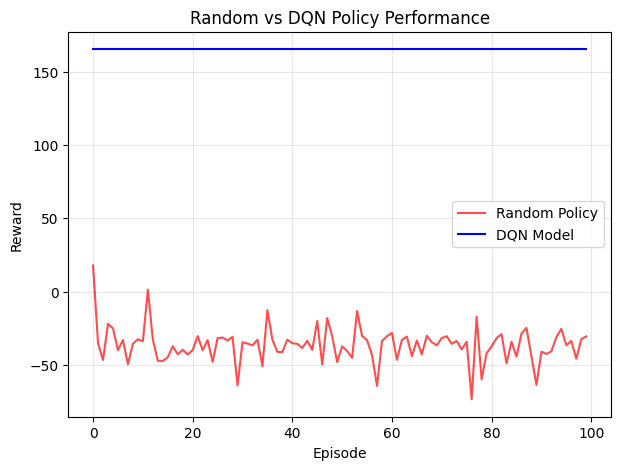

In [6]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import odeint
import scipy.io
from matplotlib.gridspec import GridSpec
import math
import random
import torch
from stable_baselines3.common.env_checker import check_env
from stable_baselines3.common.logger import configure
from stable_baselines3.common.monitor import Monitor
from stable_baselines3 import PPO 
from stable_baselines3 import DQN
# 导入 BaseCallback
from stable_baselines3.common.callbacks import BaseCallback
import sys
import os
# 导入 IEMEnv 类
from src.envs.iseec_lx_v4_pomdp import IEMEnv
from src.utils.run_debug_plot import save_data 
from src.utils.run_debug_plot import save_plot_NSM_data
from src.utils.run_debug_plot import save_plot_SSM_data
from src.utils.run_debug_plot import save_future_data
from src.utils.run_debug_plot import save_plot_NSM_future_data
from src.utils.run_debug_plot import save_plot_SSM_future_data
from src.utils.run_debug_plot import plot_episode_reward
from src.utils.run_debug_plot import plot_episode_reward_simple
from src.utils.run_debug_plot import plot_3D_run
# 将 src 目录添加到模块搜索路径
sys.path.append(os.path.abspath('src'))


# 参数配置部分
custom_reward_type = "multi_objective_all_T_a_Ca_exp122_weights_change_more_ta"
log_name = "iseec_lx_v4_mdp_plot_DQN_multi_objective_all_T_a_Ca_exp122_weights_change_more_ta_700000_default"
seed = 42
# po_mdp_state = [0, 1, 2, 3, 4]  # POMDP 状态索引
# 加载对应环境
env = IEMEnv(reward_type=custom_reward_type, seed=seed, ) #  pomdp_state_indices=po_mdp_state
# 加载初始的模型
model = DQN.load(f"./model/{log_name}", env=env)

test_episodes = 100
max_steps = 250

random_rewards = []
dqn_rewards = []

for ep in range(test_episodes):
    # --- DQN Policy ---
    obs, _ = env.reset(use_random_reset = False)
    total_reward = 0
    done = False
    for _ in range(max_steps):
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, done, _, _ = env.step(action)
        total_reward += reward
        if done:
            break
    dqn_rewards.append(total_reward)

    # --- Random Policy ---
    obs, _ = env.reset(use_random_reset = False)
    total_reward = 0
    done = False
    for _ in range(max_steps):
        action = env.action_space.sample()
        obs, reward, done, _, _ = env.step(action)
        total_reward += reward
        if done:
            break
    random_rewards.append(total_reward)

# 绘图
plt.figure(figsize=(7,5))
plt.plot(range(test_episodes), random_rewards, label="Random Policy", color='red', alpha=0.7)
plt.plot(range(test_episodes), dqn_rewards, label="DQN Model", color='blue')
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Random vs DQN Policy Performance")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


[1850 1851 1852 1853 1854 1855 1856 1857 1858 1859 1860 1861 1862 1863
 1864 1865 1866 1867 1868 1869 1870 1871 1872 1873 1874 1875 1876 1877
 1878 1879 1880 1881 1882 1883 1884 1885 1886 1887 1888 1889 1890 1891
 1892 1893 1894 1895 1896 1897 1898 1899 1900 1901 1902 1903 1904 1905
 1906 1907 1908 1909 1910 1911 1912 1913 1914 1915 1916 1917 1918 1919
 1920 1921 1922 1923 1924 1925 1926 1927 1928 1929 1930 1931 1932 1933
 1934 1935 1936 1937 1938 1939 1940 1941 1942 1943 1944 1945 1946 1947
 1948 1949 1950 1951 1952 1953 1954 1955 1956 1957 1958 1959 1960 1961
 1962 1963 1964 1965 1966 1967 1968 1969 1970 1971 1972 1973 1974 1975
 1976 1977 1978 1979 1980 1981 1982 1983 1984 1985 1986 1987 1988 1989
 1990 1991 1992 1993 1994 1995 1996 1997 1998 1999 2000 2001 2002 2003
 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013 2014 2015 2016 2017
 2018 2019 2020 2021 2022 2023 2024 2025 2026 2027 2028 2029 2030 2031
 2032 2033 2034 2035 2036 2037 2038 2039 2040 2041 2042 2043 2044 2045
 2046 

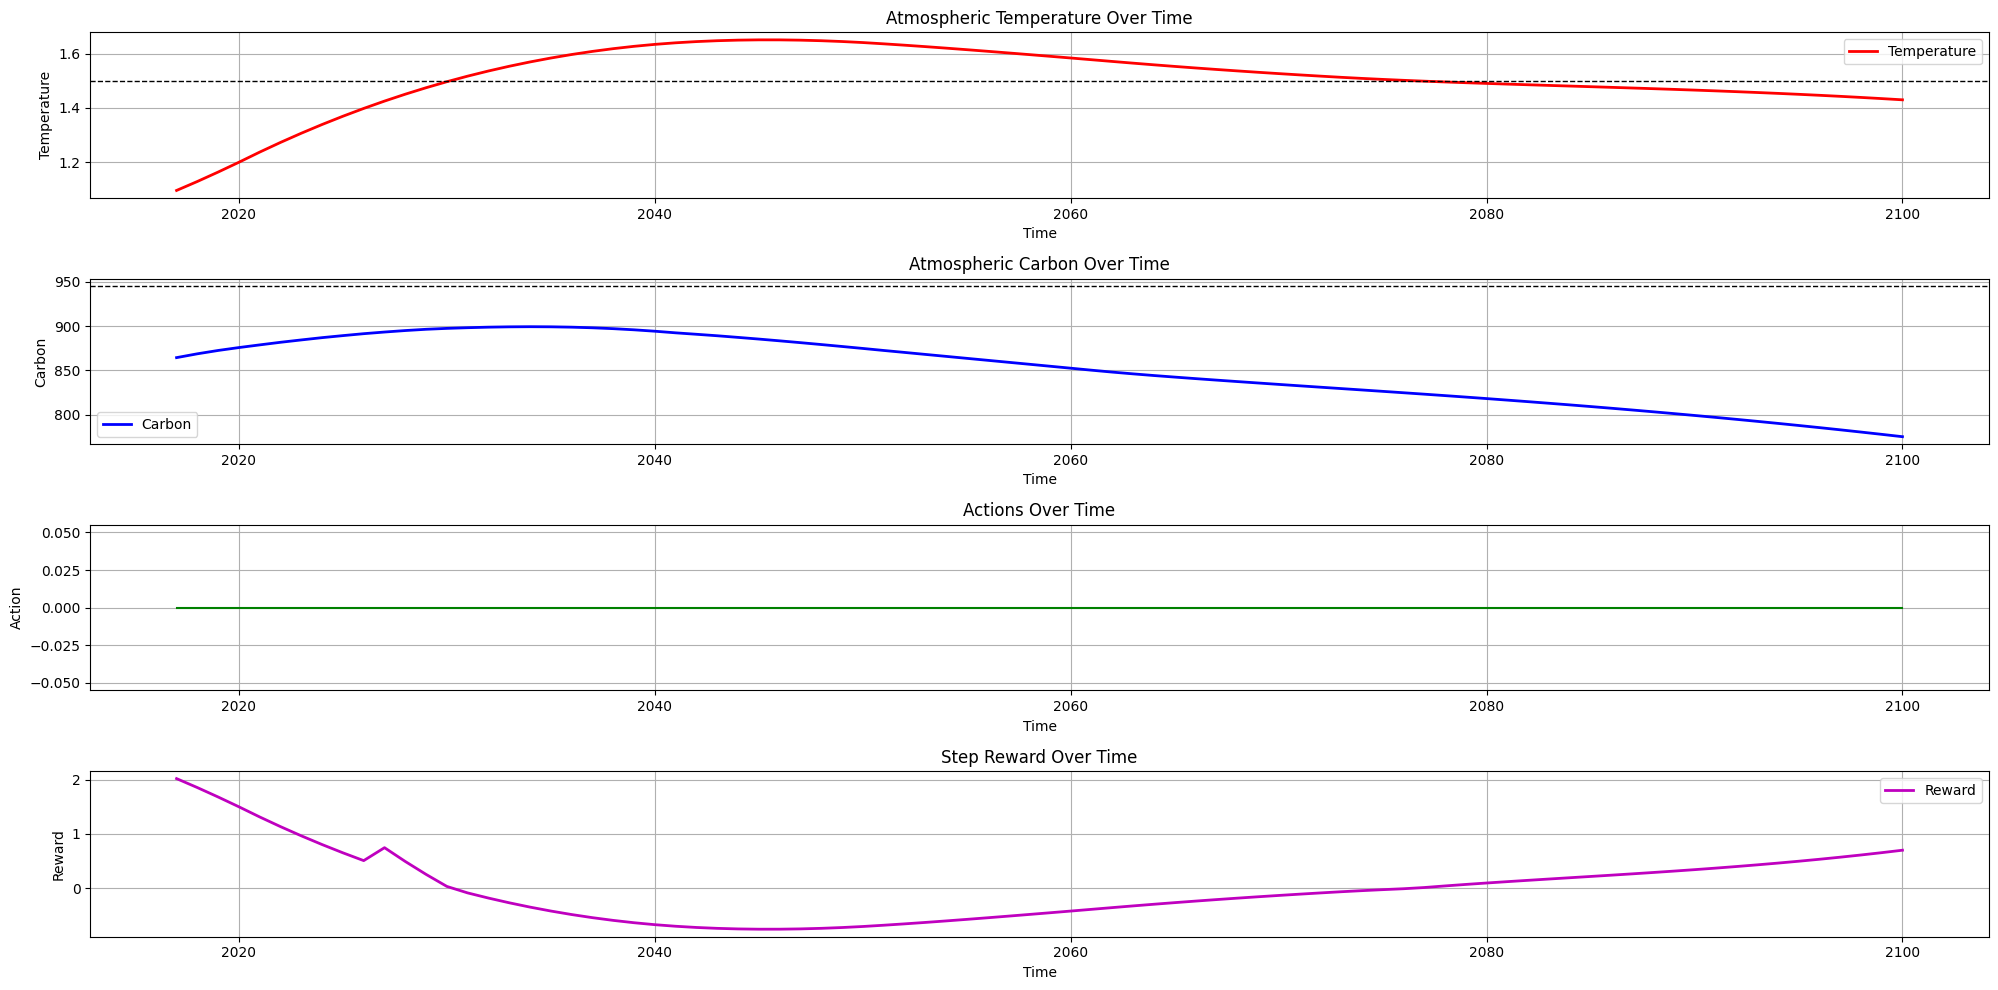

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from src.envs.iseec_lx_v4_pomdp import IEMEnv

# 初始化环境
env = IEMEnv(reward_type="multi_objective_single_T_a_exp822", seed=42)
obs, _ = env.reset(use_random_reset=False)

# 设定全程固定 action
fixed_action = 0
max_steps = env.model_end_year - env.model_init_year

rewards = []
actions = []
states = []
times = []

for _ in range(max_steps):
    obs, reward, done, _, info = env.step(fixed_action)
    rewards.append(reward)
    actions.append(fixed_action)
    states.append(env.state.copy())
    times.append(info["year"])
    if done:
        break

states = np.array(states)

# 提取你关心的变量，比如 T_a, C_a
T_a = states[:, 0]
C_a = states[:, 1]

# 绘图
fig, axs = plt.subplots(4, 1, figsize=(20, 10))

axs[0].set_title("Atmospheric Temperature Over Time")
axs[0].plot(times, T_a, "r-", linewidth=2, label="Temperature")
axs[0].axhline(y=1.5, color="k", linestyle="--", linewidth=1)
axs[0].set_xlabel("Time")
axs[0].set_ylabel("Temperature")
axs[0].legend()
axs[0].grid(True)

axs[1].set_title("Atmospheric Carbon Over Time")
axs[1].plot(times, C_a, "b-", linewidth=2, label="Carbon")
axs[1].axhline(y=945, color="k", linestyle="--", linewidth=1)
axs[1].set_xlabel("Time")
axs[1].set_ylabel("Carbon")
axs[1].legend()
axs[1].grid(True)

axs[2].set_title("Actions Over Time")
axs[2].plot(times, actions, "g-")
axs[2].set_xlabel("Time")
axs[2].set_ylabel("Action")
axs[2].grid(True)

axs[3].set_title("Step Reward Over Time")
axs[3].plot(times, rewards, "m-", linewidth=2, label="Reward")
axs[3].set_xlabel("Time")
axs[3].set_ylabel("Reward")
axs[3].legend()
axs[3].grid(True)

plt.tight_layout()
plt.show()

[1850 1851 1852 1853 1854 1855 1856 1857 1858 1859 1860 1861 1862 1863
 1864 1865 1866 1867 1868 1869 1870 1871 1872 1873 1874 1875 1876 1877
 1878 1879 1880 1881 1882 1883 1884 1885 1886 1887 1888 1889 1890 1891
 1892 1893 1894 1895 1896 1897 1898 1899 1900 1901 1902 1903 1904 1905
 1906 1907 1908 1909 1910 1911 1912 1913 1914 1915 1916 1917 1918 1919
 1920 1921 1922 1923 1924 1925 1926 1927 1928 1929 1930 1931 1932 1933
 1934 1935 1936 1937 1938 1939 1940 1941 1942 1943 1944 1945 1946 1947
 1948 1949 1950 1951 1952 1953 1954 1955 1956 1957 1958 1959 1960 1961
 1962 1963 1964 1965 1966 1967 1968 1969 1970 1971 1972 1973 1974 1975
 1976 1977 1978 1979 1980 1981 1982 1983 1984 1985 1986 1987 1988 1989
 1990 1991 1992 1993 1994 1995 1996 1997 1998 1999 2000 2001 2002 2003
 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013 2014 2015 2016 2017
 2018 2019 2020 2021 2022 2023 2024 2025 2026 2027 2028 2029 2030 2031
 2032 2033 2034 2035 2036 2037 2038 2039 2040 2041 2042 2043 2044 2045
 2046 

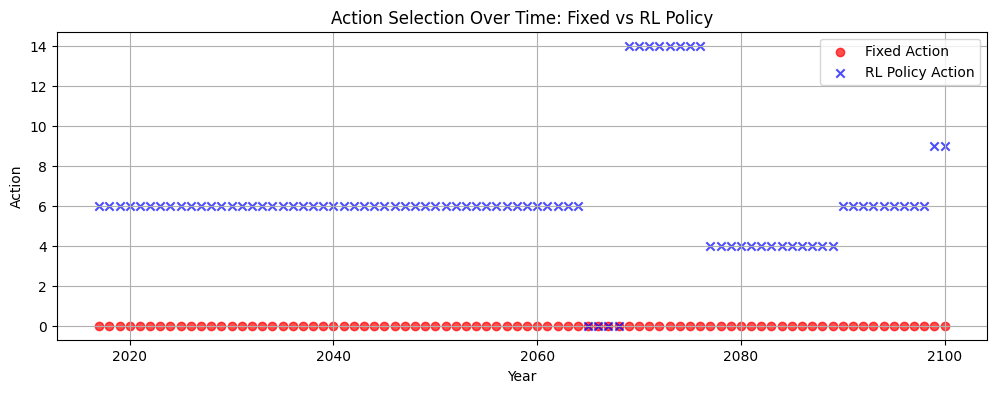

In [9]:
import matplotlib.pyplot as plt
from src.envs.iseec_lx_v4_pomdp import IEMEnv
from stable_baselines3 import DQN

# 1. 固定 action
env = IEMEnv(reward_type="multi_objective_single_T_a_exp822", seed=42)
obs, _ = env.reset(use_random_reset=False)
fixed_action = 0
fixed_actions = []
fixed_times = []

for _ in range(env.model_end_year - env.model_init_year):
    obs, reward, done, _, info = env.step(fixed_action)
    fixed_actions.append(fixed_action)
    fixed_times.append(info["year"])
    if done:
        break

# 2. RL policy action
env2 = IEMEnv(reward_type="multi_objective_single_T_a_exp822", seed=42)
model = DQN.load("./model/iseec_lx_v4_mdp_plot_DQN_multi_objective_single_T_a_exp822_700000_default", env=env2)
obs, _ = env2.reset(use_random_reset=False)
policy_actions = []
policy_times = []

for _ in range(env2.model_end_year - env2.model_init_year):
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, done, _, info = env2.step(action)
    policy_actions.append(action)
    policy_times.append(info["year"])
    if done:
        break

# 3. 绘制对比散点图
plt.figure(figsize=(12, 4))
plt.scatter(fixed_times, fixed_actions, color='red', label='Fixed Action', marker='o', alpha=0.7)
plt.scatter(policy_times, policy_actions, color='blue', label='RL Policy Action', marker='x', alpha=0.7)
plt.xlabel("Year")
plt.ylabel("Action")
plt.title("Action Selection Over Time: Fixed vs RL Policy")
plt.legend()
plt.grid(True)
plt.show()

[1850 1851 1852 1853 1854 1855 1856 1857 1858 1859 1860 1861 1862 1863
 1864 1865 1866 1867 1868 1869 1870 1871 1872 1873 1874 1875 1876 1877
 1878 1879 1880 1881 1882 1883 1884 1885 1886 1887 1888 1889 1890 1891
 1892 1893 1894 1895 1896 1897 1898 1899 1900 1901 1902 1903 1904 1905
 1906 1907 1908 1909 1910 1911 1912 1913 1914 1915 1916 1917 1918 1919
 1920 1921 1922 1923 1924 1925 1926 1927 1928 1929 1930 1931 1932 1933
 1934 1935 1936 1937 1938 1939 1940 1941 1942 1943 1944 1945 1946 1947
 1948 1949 1950 1951 1952 1953 1954 1955 1956 1957 1958 1959 1960 1961
 1962 1963 1964 1965 1966 1967 1968 1969 1970 1971 1972 1973 1974 1975
 1976 1977 1978 1979 1980 1981 1982 1983 1984 1985 1986 1987 1988 1989
 1990 1991 1992 1993 1994 1995 1996 1997 1998 1999 2000 2001 2002 2003
 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013 2014 2015 2016 2017
 2018 2019 2020 2021 2022 2023 2024 2025 2026 2027 2028 2029 2030 2031
 2032 2033 2034 2035 2036 2037 2038 2039 2040 2041 2042 2043 2044 2045
 2046 

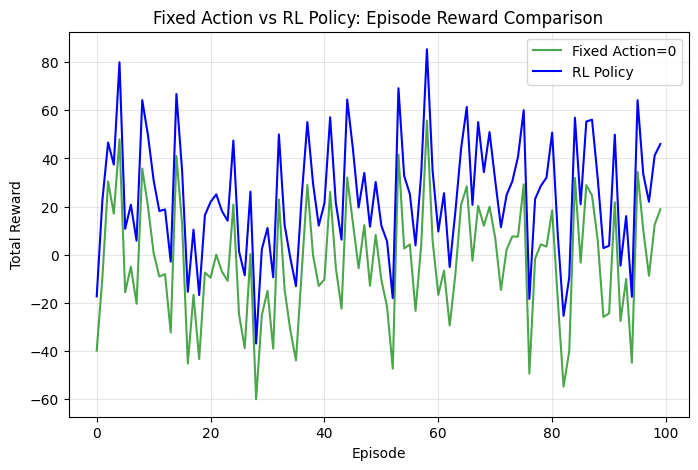

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from src.envs.iseec_lx_v4_pomdp import IEMEnv
from stable_baselines3 import DQN

# 配置
reward_type = "multi_objective_single_T_a_exp822"
model_path = "./model/iseec_lx_v4_mdp_plot_DQN_multi_objective_single_T_a_exp822_700000_default"
seed = 42
test_episodes = 100
max_steps = 250
fixed_action = 0

# 固定 action
env = IEMEnv(reward_type=reward_type, seed=seed)
fixed_rewards = []
for ep in range(test_episodes):
    obs, _ = env.reset()
    total_reward = 0
    done = False
    for _ in range(max_steps):
        obs, reward, done, _, _ = env.step(fixed_action)
        total_reward += reward
        if done:
            break
    fixed_rewards.append(total_reward)

# RL policy
env2 = IEMEnv(reward_type=reward_type, seed=seed)
model = DQN.load(model_path, env=env2)
policy_rewards = []
for ep in range(test_episodes):
    obs, _ = env2.reset()
    total_reward = 0
    done = False
    for _ in range(max_steps):
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, done, _, _ = env2.step(action)
        total_reward += reward
        if done:
            break
    policy_rewards.append(total_reward)

# 绘制对比
plt.figure(figsize=(8,5))
plt.plot(fixed_rewards, label=f"Fixed Action={fixed_action}", color='green', alpha=0.7)
plt.plot(policy_rewards, label="RL Policy", color='blue')
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Fixed Action vs RL Policy: Episode Reward Comparison")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

[1850 1851 1852 1853 1854 1855 1856 1857 1858 1859 1860 1861 1862 1863
 1864 1865 1866 1867 1868 1869 1870 1871 1872 1873 1874 1875 1876 1877
 1878 1879 1880 1881 1882 1883 1884 1885 1886 1887 1888 1889 1890 1891
 1892 1893 1894 1895 1896 1897 1898 1899 1900 1901 1902 1903 1904 1905
 1906 1907 1908 1909 1910 1911 1912 1913 1914 1915 1916 1917 1918 1919
 1920 1921 1922 1923 1924 1925 1926 1927 1928 1929 1930 1931 1932 1933
 1934 1935 1936 1937 1938 1939 1940 1941 1942 1943 1944 1945 1946 1947
 1948 1949 1950 1951 1952 1953 1954 1955 1956 1957 1958 1959 1960 1961
 1962 1963 1964 1965 1966 1967 1968 1969 1970 1971 1972 1973 1974 1975
 1976 1977 1978 1979 1980 1981 1982 1983 1984 1985 1986 1987 1988 1989
 1990 1991 1992 1993 1994 1995 1996 1997 1998 1999 2000 2001 2002 2003
 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013 2014 2015 2016 2017
 2018 2019 2020 2021 2022 2023 2024 2025 2026 2027 2028 2029 2030 2031
 2032 2033 2034 2035 2036 2037 2038 2039 2040 2041 2042 2043 2044 2045
 2046 

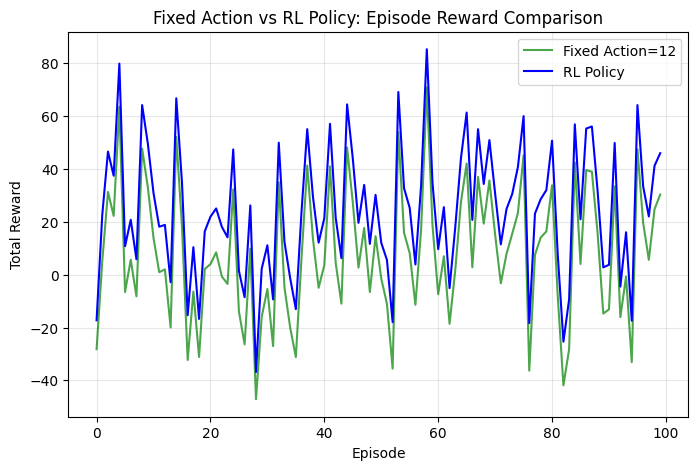

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from src.envs.iseec_lx_v4_pomdp import IEMEnv
from stable_baselines3 import DQN

# 配置
reward_type = "multi_objective_single_T_a_exp822"
model_path = "./model/iseec_lx_v4_mdp_plot_DQN_multi_objective_single_T_a_exp822_700000_default"
seed = 42
test_episodes = 100
max_steps = 250
fixed_action = 12

# 固定 action
env = IEMEnv(reward_type=reward_type, seed=seed)
fixed_rewards = []
for ep in range(test_episodes):
    obs, _ = env.reset()
    total_reward = 0
    done = False
    for _ in range(max_steps):
        obs, reward, done, _, _ = env.step(fixed_action)
        total_reward += reward
        if done:
            break
    fixed_rewards.append(total_reward)

# RL policy
env2 = IEMEnv(reward_type=reward_type, seed=seed)
model = DQN.load(model_path, env=env2)
policy_rewards = []
for ep in range(test_episodes):
    obs, _ = env2.reset()
    total_reward = 0
    done = False
    for _ in range(max_steps):
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, done, _, _ = env2.step(action)
        total_reward += reward
        if done:
            break
    policy_rewards.append(total_reward)

# 绘制对比
plt.figure(figsize=(8,5))
plt.plot(fixed_rewards, label=f"Fixed Action={fixed_action}", color='green', alpha=0.7)
plt.plot(policy_rewards, label="RL Policy", color='blue')
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Fixed Action vs RL Policy: Episode Reward Comparison")
plt.legend()
plt.grid(alpha=0.3)
plt.show()
